In [1]:
import numpy as np
import torch
import scanpy as sc
import pandas as pd
import os
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score as ari_score
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from sklearn.decomposition import PCA


In [2]:
import numpy as np
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

ro.r('''
mclust_classify <- function(X, G) {
  suppressMessages(library(mclust))
  X <- unname(as.matrix(X))
  G <- as.integer(G)[1]
  res <- Mclust(X, G=G)
  return(res$classification)
}
''')


In [3]:
def mclust_R(adata, num_cluster, modelNames='None', used_obsm='latent', key_added_pred='mclust', random_seed=24):
    import numpy as np
    import pandas as pd
    import rpy2.robjects as ro

    X = np.asarray(adata.obsm[used_obsm], dtype=np.float64)
    ro.r['set.seed'](int(random_seed))

    # 构造 R matrix（column-major）
    n, p = X.shape
    rX = ro.r.matrix(ro.FloatVector(X.reshape(-1, order='F')), nrow=n, ncol=p)

    # 调用 R wrapper，返回分类
    cls = np.array(ro.r['mclust_classify'](rX, int(num_cluster)), dtype=int)

    adata.obs[key_added_pred] = pd.Categorical(cls.astype(str))
    return adata



In [4]:
from utils.Func import *
from utils.Utils import *
from ProST import ProST

In [5]:
with open('./config/DLPFC_CLFS.yaml', 'r', encoding='utf-8') as f:
    config = yaml.load(f.read(), Loader=yaml.FullLoader)

In [6]:
proj_name = '151675'
num_clusters = 5 if proj_name in ['151669', '151670', '151671', '151672'] else 7

In [7]:
def off_the_shelf_adata(proj_name):
    adata = sc.read_h5ad(f'data/{proj_name}.h5ad')
    return adata

adata = off_the_shelf_adata('151675')

from utils.Func import graph_construction_multirel

graph_dict = graph_construction_multirel(
    adata,
    n_spatial=config['data']['k_cutoff'],
    n_gene=6,
    n_img=6,
    spatial_radius=70,
    constrain_gene_by_spatial=True,
    constrain_img_by_spatial=True,
    gene_key='X_pca',
    img_key='img_pca',
)

/root/miniconda3/lib/python3.10/site-packages/scipy/sparse/_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/root/miniconda3/lib/python3.10/site-packages/scipy/sparse/_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/root/miniconda3/lib/python3.10/site-packages/scipy/sparse/_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/root/autodl-tmp/ProSTpro/utils/Func.py:68: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:605.)
  return torch.sparse.FloatTensor(indices, values,

In [8]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
net = ProST(adata, graph_dict=graph_dict, num_clusters=num_clusters, device=device, config=config)
config['train']['epochs'] = 100
para_list = net.train()

X stats: mean=-0.0000, std=1.7599, min=-30.5751, max=126.5099
img stats: mean=0.0109, std=1.2543, min=-6.6554, max=7.2589


/root/miniconda3/lib/python3.10/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
E99 total=0.232 rec=0.492 cont=0.351 grad=0.08 rep_std=1.534: 100%|██████████| 100/100 [01:32<00:00,  1.08it/s]


In [9]:
enc_rep, recon = net.process()
enc_rep = enc_rep.data.cpu().numpy()
recon = recon.data.cpu().numpy()
adata.obsm['latent'] = enc_rep
adata.obsm['recon'] = recon

In [10]:
adata = mclust_R(adata, num_cluster=num_clusters, used_obsm='latent', key_added_pred='mclust')
adata.obs['domain'] = refine_label(adata, 30, key='mclust')
sub_adata = adata[~pd.isnull(adata.obs['layer_guess'])]
ARI = ari_score(sub_adata.obs['layer_guess'], sub_adata.obs['domain'])
print("ARI:", ARI)

fitting ...
  |======================================================================| 100%
ARI: 0.6785205018250482


In [11]:
X = np.asarray(adata.obsm["latent"])
print("shape:", X.shape, "dtype:", X.dtype)

shape: (3592, 16) dtype: float32


In [12]:
# 过滤掉 layer_guess 为 NaN 的 spot
adata_filtered = adata[adata.obs['layer_guess'].notna()].copy()

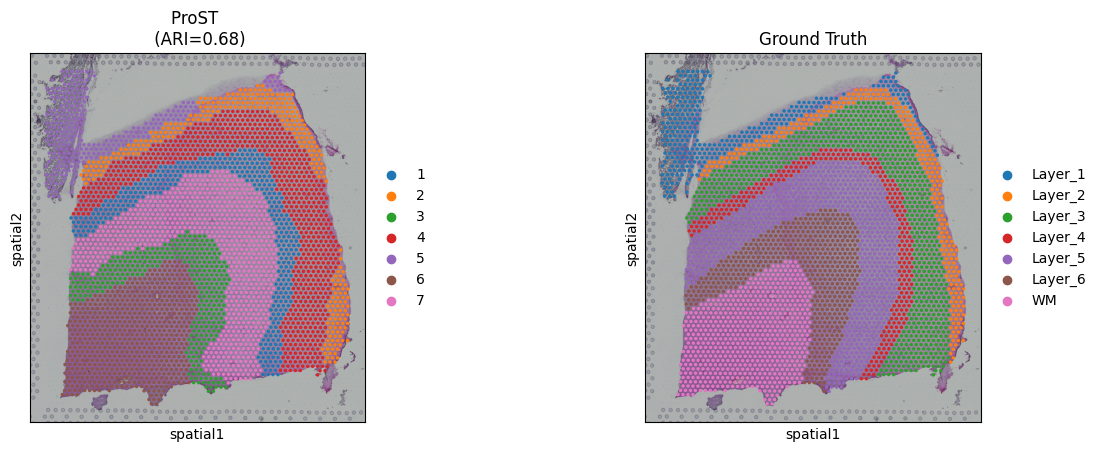

In [13]:
sc.pl.spatial(adata_filtered, color=["domain", "layer_guess"], title=[f"ProST \n (ARI={ARI:.2f})", "Ground Truth"])